# 🎓 Class 07 — Student Mental Health Dataset: Feature Engineering, Custom Encoding & SMOTE

## 📌 ভূমিকা (Introduction)

এই নোটবুকে আমরা একটি **Student Mental Health & Entrepreneurship Survey Dataset** নিয়ে কাজ করব।

এই Class-এ আমরা নতুন কিছু শিখব যা আগে শিখিনি:

- **Manual Mapping** দিয়ে Custom Encoding — Label Encoder নয়, নিজে বুঝে বুঝে Encode করা
- **Feature Engineering** — একাধিক Column থেকে নতুন একটি `score` Column তৈরি করা
- **Custom Function** দিয়ে Score কে Category তে ভাগ করা
- **Class Imbalance** সমস্যা কী এবং **SMOTE** দিয়ে সেটা সমাধান করা

### আমাদের লক্ষ্য (Our Task):
- Dataset লোড, Explore ও Clean করা
- `Timestamp` ও অপ্রয়োজনীয় Column মুছে ফেলা
- **Manual Dictionary Mapping** দিয়ে প্রতিটি Column Encode করা
- ৫টি Entrepreneurship-related Column থেকে গড় বের করে `score` Column তৈরি করা
- Score-এর উপর ভিত্তি করে **Low / Medium / High** Label তৈরি করা
- Class Distribution দেখা ও **SMOTE** দিয়ে Imbalance সমাধান করা

---

### 🧠 Label Encoder vs Manual Mapping — পার্থক্য কী?

আগের Class-এ আমরা `LabelEncoder` ব্যবহার করেছিলাম — সেটা Alphabetical Order অনুযায়ী স্বয়ংক্রিয়ভাবে সংখ্যা দেয়।

কিন্তু এই Dataset-এ কিছু Column-এ **Ordinal Order** আছে — যেমন CGPA:
- `Below 2.50` < `2.50-2.99` < `3.00-3.49` < `3.50-3.74` < `3.75-4.00`

এই ক্রম LabelEncoder বুঝবে না (Alphabetical করবে)। তাই আমরা নিজে **Dictionary** তৈরি করে সঠিক সংখ্যা assign করব।

| পদ্ধতি | কে সংখ্যা ঠিক করে | Order ঠিক থাকে? |
|---|---|---|
| `LabelEncoder` | Sklearn (Alphabetical) | ❌ না |
| **Manual Mapping** | আমরা নিজে | ✅ হ্যাঁ |

---

## 🐼 প্রয়োজনীয় Library Import

`seaborn` এবার নতুন যোগ হয়েছে — সুন্দর Statistical Visualization-এর জন্য।

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Dataset লোড করা

`5048.csv` — এই Dataset-এ University Students-দের CGPA, Study Hours, Program, Gender এবং Entrepreneurship সম্পর্কিত মনোভাবের Survey Data আছে।

In [23]:
df=pd.read_csv('/content/5048.csv')

## 👀 Dataset দেখা ও Null Value চেক

In [24]:
df

,Timestamp,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.
0,10/28/2024 22:39,Female,19,Social Sciences,1st year,3.00 - 3.49,Less than 5 hours,1,2,4,1,1,2,1,3
1,10/28/2024 22:50,Female,22,Engineering/Technology,2nd year,3.75 - 4.00,5-10 hours,5,4,4,4,4,5,5,6
2,10/28/2024 22:51,Female,20,Business/Entrepreneurship,1st year,2.50 - 2.99,Less than 5 hours,2,2,1,5,4,3,4,3
3,10/28/2024 22:51,Male,23,Engineering/Technology,3rd year,2.50 - 2.99,11-15 hours,3,3,1,5,5,3,5,4
4,10/28/2024 22:54,Male,25,Social Sciences,4th year,3.75 - 4.00,More than 15 hours,5,4,3,3,3,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,11/10/2024 20:10,Female,23,Engineering/Technology,3rd year,3.50 - 3.74,5-10 hours,3,3,2,5,4,5,4,5
404,11/10/2024 20:11,Male,23,Business/Entrepreneurship,2nd year,3.50 - 3.74,5-10 hours,4,4,3,7,7,7,7,7
405,11/10/2024 20:12,Male,22,Social Sciences,3rd year,3.50 - 3.74,5-10 hours,4,3,4,5,7,5,7,5
406,11/12/2024 21:35,Female,23,Social Sciences,3rd year,3.50 - 3.74,More than 15 hours,4,3,2,7,5,2,4,2


In [25]:
df.isnull().sum()

,0
Timestamp,0
What is your Gender?,0
What is your Age?,0
Program / Major,0
What year are you in at university?,0
What is your current overall CGPA?,0
Average Weekly Study Hours?,0
Attend all scheduled classes:,0
Complete all assignments on time,0
Review course material regularly,0


## 👥 Gender Distribution দেখা

**Male koyta ar Female koyta ta bole dibe** ✅

`value_counts()` দিয়ে গণনা, `hist()` দিয়ে Visual দেখা।

In [26]:
df["What is your Gender?"].value_counts()

,count
What is your Gender?,
Male,221
Female,187


<Axes: >

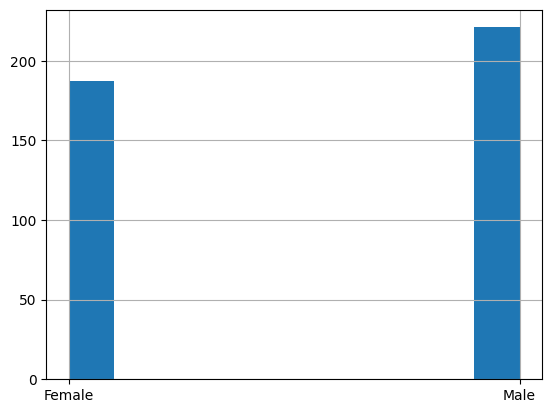

In [27]:
df["What is your Gender?"].hist()

## 🗑️ Timestamp Column Drop করা

**Drop Timestamp Dataset** ✅

`Timestamp` Column শুধু Survey জমার সময় রেকর্ড করে — ML Model-এ কোনো কাজে আসে না, তাই `axis=1, inplace=True` দিয়ে Drop করা হচ্ছে।

> ⚠️ **মনে রাখো:** `axis=1` মানে Column বরাবর কাজ করো (Column মুছবে), `inplace=True` মানে Original `df`-তেই পরিবর্তন সংরক্ষণ করো।

In [28]:
# dataset.drop("Timestamp")  # eikhane timestamp ke row onujai khuja hoy.Tohn axix er man 0 thake .but eita ase column onujai. tai axix=1 hbe. but tateo hbe na. implace true lagbe
df.drop("Timestamp",axis=1, inplace=True)

In [29]:
df

,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.
0,Female,19,Social Sciences,1st year,3.00 - 3.49,Less than 5 hours,1,2,4,1,1,2,1,3
1,Female,22,Engineering/Technology,2nd year,3.75 - 4.00,5-10 hours,5,4,4,4,4,5,5,6
2,Female,20,Business/Entrepreneurship,1st year,2.50 - 2.99,Less than 5 hours,2,2,1,5,4,3,4,3
3,Male,23,Engineering/Technology,3rd year,2.50 - 2.99,11-15 hours,3,3,1,5,5,3,5,4
4,Male,25,Social Sciences,4th year,3.75 - 4.00,More than 15 hours,5,4,3,3,3,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,Female,23,Engineering/Technology,3rd year,3.50 - 3.74,5-10 hours,3,3,2,5,4,5,4,5
404,Male,23,Business/Entrepreneurship,2nd year,3.50 - 3.74,5-10 hours,4,4,3,7,7,7,7,7
405,Male,22,Social Sciences,3rd year,3.50 - 3.74,5-10 hours,4,3,4,5,7,5,7,5
406,Female,23,Social Sciences,3rd year,3.50 - 3.74,More than 15 hours,4,3,2,7,5,2,4,2


## 🔍 Dataset-এর তথ্য দেখা — `df.info()`

`df.info()` প্রতিটি Column-এর:
- **Data Type** (object = Text, int64/float64 = সংখ্যা)
- **Non-Null Count** (কতটি Non-missing মান আছে)
- **মোট মেমোরি ব্যবহার**

এটি দেখে বোঝা যাবে কোন Column-গুলো এখনো Text (object) আকারে আছে — সেগুলোই Encode করতে হবে।

> 💡 **টিপস:** সব Column `object` type দেখালে বুঝবে সেগুলো এখনো Text — ML Model-এ দেওয়ার আগে সংখ্যায় বদলাতে হবে।

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 14 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   What is your Gender?                                                 408 non-null    object
 1   What is your Age?                                                    408 non-null    int64 
 2   Program / Major                                                      408 non-null    object
 3   What year are you in at university?                                  408 non-null    object
 4   What is your current overall CGPA?                                   408 non-null    object
 5   Average Weekly Study Hours?                                          408 non-null    object
 6   Attend all scheduled classes:                                        408 non-null    int64 
 7   Complete all assi

## 👤 Gender Encoding — Manual Dictionary Mapping

### 🧠 বিস্তারিত থিওরি

প্রথমে `unique()` দিয়ে Gender Column-এ কী কী Unique মান আছে দেখা হচ্ছে।

তারপর একটি **Dictionary (gm)** তৈরি করা হচ্ছে:
```python
gm = {'Male': 0, 'Female': 1}
```

এরপর `.map(gm)` ব্যবহার করে পুরো Column-এর প্রতিটি মানকে Dictionary অনুযায়ী সংখ্যায় বদলানো হচ্ছে।

### `.map()` vs `LabelEncoder` — কোনটা কখন?

| পরিস্থিতি | ব্যবহার করো |
|---|---|
| Alphabetical Order যথেষ্ট, Ordinal নেই | `LabelEncoder` |
| নিজে Order ঠিক করতে চাই | `.map(dictionary)` |
| যখন Ordinal Data (যেমন Low < Medium < High) | **অবশ্যই `.map()`** |

> ⚠️ **সাধারণ ভুল:** Dictionary-তে Spelling হুবহু মিলতে হবে। `'male'` আর `'Male'` আলাদা — ছোট-বড় হাতের পার্থক্যে `NaN` চলে আসবে।

In [31]:
df['What is your Gender?'].unique()

array(['Female', 'Male'], dtype=object)

In [34]:
gm={'Male': 0, 'Female': 1}
df["What is your Gender?"]=df["What is your Gender?"].map(gm)


In [35]:
df["What is your Gender?"]

,What is your Gender?
0,1
1,1
2,1
3,0
4,0
...,...
403,1
404,0
405,0
406,1


## 🎓 CGPA Encoding – Ordinal Manual Mapping

### 🧠 বিস্তারিত থিওরি

`unique()` দিয়ে দেখা হচ্ছে CGPA Column-এ কী কী Range আছে।

এই Column-এ **স্পষ্ট Ordinal Order** আছে:

* `Below 2.50` < `2.50-2.99` < `3.00-3.49` < `3.50-3.74` < `3.75-4.00`
* এদের সঠিক ম্যাপিং বা অর্ডার হওয়া উচিত: `0, 1, 2, 3, 4`

---

> ⚠️ **সতর্কতা:** এখানে সাধারণ `LabelEncoder` ব্যবহার করলে সে ডাটাকে **Alphabetically (অক্ষর অনুযায়ী)** sort করত, যা এই ক্ষেত্রে সম্পূর্ণ ভুল আউটপুট দিত।

#### ❌ LabelEncoder-এর ভুল ম্যাপিং উদাহরণ:
* `'3.00 - 3.49'` $\rightarrow$ `0`
* `'3.50 - 3.74'` $\rightarrow$ `1`
* `'3.75 - 4.00'` $\rightarrow$ `2`
* `'Below 2.50'` $\rightarrow$ `3` **(যা সম্পূর্ণ ভুল! কারণ এটি সবচেয়ে ছোট ভ্যালু হওয়ার কথা ছিল)**

তাই **Manual Mapping অবশ্যই দরকার** — নইলে Model ভুল Order শিখবে।

> 💡 **মনে রাখো:** যখনই কোনো Text Column-এ একটি স্বাভাবিক ক্রম (Rank/Order) আছে — সেটা নিজে Dictionary দিয়ে Encode করো।

In [36]:
df['What is your current overall CGPA?'].unique()

array(['3.00 - 3.49', '3.75 - 4.00', '2.50 - 2.99', 'Below 2.50',
       '3.50 - 3.74'], dtype=object)

In [37]:
cgpa = {
    '3.75 - 4.00': 4,
    '3.50 - 3.74': 3,
    '3.00 - 3.49': 2,
    '2.50 - 2.99': 1,
    'Below 2.50': 0
}
df['What is your current overall CGPA?'] = df['What is your current overall CGPA?'].map(cgpa)

In [38]:
df['What is your current overall CGPA?']

,What is your current overall CGPA?
0,2
1,4
2,1
3,1
4,4
...,...
403,3
404,3
405,3
406,3


## 📅 University Year Encoding

### 🧠 কেন Manual Mapping?

`1st year < 2nd year < 3rd year < 4th year` — এখানেও স্পষ্ট Order আছে। LabelEncoder Alphabetically করলে ভুল ক্রম হবে। তাই:

```python
'1st year' → 0
'2nd year' → 1
'3rd year' → 2
'4th year' → 3
```

> ⚠️ **আগে `value_counts()` দিয়ে দেখা হচ্ছে** — কতজন কোন Year-এ আছে এবং Spelling ঠিক আছে কিনা নিশ্চিত করতে।

In [39]:
df["What year are you in at university?"].value_counts()

,count
What year are you in at university?,
3rd year,125
2nd year,117
1st year,96
4th year,70


## 📅 University Year Encoding

### 🧠 কেন Manual Mapping?

`1st year < 2nd year < 3rd year < 4th year` — এখানেও স্পষ্ট Order আছে। LabelEncoder Alphabetically করলে ভুল ক্রম হবে। তাই:

```python
'1st year' → 0
'2nd year' → 1
'3rd year' → 2
'4th year' → 3
```

> ⚠️ **আগে `value_counts()` দিয়ে দেখা হচ্ছে** — কতজন কোন Year-এ আছে এবং Spelling ঠিক আছে কিনা নিশ্চিত করতে।

In [40]:
df["What year are you in at university?"].value_counts()

,count
What year are you in at university?,
3rd year,125
2nd year,117
1st year,96
4th year,70


In [41]:
year_mapping = {
    '1st year': 0,
    '2nd year': 1,
    '3rd year': 2,
    '4th year': 3
}

df['What year are you in at university?'] = df['What year are you in at university?'].map(year_mapping)

In [42]:
df['What year are you in at university?']

,What year are you in at university?
0,0
1,1
2,0
3,2
4,3
...,...
403,2
404,1
405,2
406,2


## ⏰ Study Hours Encoding

### 🧠 কেন Manual Mapping?

`Less than 5` < `5-10` < `11-15` < `More than 15` — এটাও Ordinal। কম ঘণ্টা থেকে বেশি ঘণ্টায় যাওয়ার একটি স্বাভাবিক ক্রম আছে।

> ⚠️ **আগে `value_counts()`** — কতজন কত ঘণ্টা পড়ে তা দেখা এবং Exact Spelling যাচাই করা হচ্ছে। Dictionary-তে Spelling একটুও আলাদা হলে `NaN` আসবে।

In [43]:
df["Average Weekly Study Hours?"].value_counts()

,count
Average Weekly Study Hours?,
11-15 hours,128
5-10 hours,120
Less than 5 hours,100
More than 15 hours,60


In [44]:
study_hours = {
    'Less than 5 hours': 0,
    '5-10 hours': 1,
    '11-15 hours': 2,
    'More than 15 hours': 3
}

df['Average Weekly Study Hours?'] = df['Average Weekly Study Hours?'].map(study_hours)

In [45]:
df['Average Weekly Study Hours?']

,Average Weekly Study Hours?
0,0
1,1
2,0
3,2
4,3
...,...
403,1
404,1
405,1
406,3


## 🎓 Program / Major Encoding

### 🧠 এটা Ordinal নয় — তবুও Manual Mapping কেন?

`Program / Major` Column-এ কোনো Natural Order নেই — Social Sciences, Engineering, Business, Arts সবগুলো সমান গুরুত্বের। এখানে LabelEncoder ব্যবহার করা যেত। কিন্তু Manual Mapping করা হচ্ছে কারণ:

1. কোন সংখ্যা কোন Program-এর সেটা নিজে নিয়ন্ত্রণ করা যায়
2. পরে কোড বুঝতে সহজ হয়

> ⚠️ **মনে রাখো:** Nominal Data (কোনো Order নেই) এর জন্য আসলে **One-Hot Encoding** আদর্শ — কিন্তু এখানে সহজতার জন্য Manual Mapping ব্যবহার করা হচ্ছে।

In [46]:
df['Program / Major'].value_counts()

,count
Program / Major,
Engineering/Technology,134
Business/Entrepreneurship,103
Social Sciences,86
Arts and Humanities,85


In [47]:
program_mapping = {
    'Social Sciences': 0,
    'Engineering/Technology': 1,
    'Business/Entrepreneurship': 2,
    'Arts and Humanities': 3
}

df['Program / Major'] = df['Program / Major'].map(program_mapping)

In [48]:
 df['Program / Major']

,Program / Major
0,0
1,1
2,2
3,1
4,0
...,...
403,1
404,2
405,0
406,0


In [49]:
df

,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.
0,1,19,0,0,2,0,1,2,4,1,1,2,1,3
1,1,22,1,1,4,1,5,4,4,4,4,5,5,6
2,1,20,2,0,1,0,2,2,1,5,4,3,4,3
3,0,23,1,2,1,2,3,3,1,5,5,3,5,4
4,0,25,0,3,4,3,5,4,3,3,3,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1,23,1,2,3,1,3,3,2,5,4,5,4,5
404,0,23,2,1,3,1,4,4,3,7,7,7,7,7
405,0,22,0,2,3,1,4,3,4,5,7,5,7,5
406,1,23,0,2,3,3,4,3,2,7,5,2,4,2


# 🔧 Feature Engineering — নতুন `score` Column তৈরি করা

## 🧠 বিস্তারিত থিওরি

এই Dataset-এ Entrepreneurship সম্পর্কিত **৫টি আলাদা Column** আছে, যেমন:
- "আমি উদ্যোক্তা হতে যেকোনো কিছু করতে রাজি"
- "আমার লক্ষ্য উদ্যোক্তা হওয়া"
- ইত্যাদি

এই ৫টি Column আলাদাভাবে ML Model-এ দিলে Model confuse হতে পারে। তাছাড়া এগুলো একই বিষয় (Entrepreneurship Intention) মাপছে।

**বুদ্ধিমানের কাজ হলো:** এই ৫টি Column-এর **গড় (Mean)** বের করে একটি নতুন `score` Column তৈরি করা — যা Entrepreneurship Intention-এর একটি সামগ্রিক সূচক।

$$\text{score} = \frac{\text{Col}_1 + \text{Col}_2 + \text{Col}_3 + \text{Col}_4 + \text{Col}_5}{5}$$

### `dc.mean(axis=1)` কেন?

- `axis=0` → প্রতিটি Column-এর গড় (উপর থেকে নিচে)
- **`axis=1`** → প্রতিটি Row-এর গড় (বামে থেকে ডানে) ✅

আমরা চাই প্রতিটি ছাত্রের ৫টি প্রশ্নের গড় — তাই `axis=1`।

> ⚠️ **সাধারণ ভুল:** `axis=0` দিলে পুরো Column-এর গড় একটি সংখ্যা আসবে — Row-wise গড় আসবে না। এটা এই ক্ষেত্রে ভুল হবে।

In [50]:
dc= df[[
    'I am ready to do anything to be an entrepreneur.',
    'My professional goal is to become an entrepreneur.',
    'I will make every effort to start and run my own business.',
    'I have seriously thought of starting my own business in the future.',
    'I am determined to create a firm in the future.'
]]

df['score'] = dc.mean(axis=1)


In [51]:
df

,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.,score
0,1,19,0,0,2,0,1,2,4,1,1,2,1,3,1.6
1,1,22,1,1,4,1,5,4,4,4,4,5,5,6,4.8
2,1,20,2,0,1,0,2,2,1,5,4,3,4,3,3.8
3,0,23,1,2,1,2,3,3,1,5,5,3,5,4,4.4
4,0,25,0,3,4,3,5,4,3,3,3,3,1,1,2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1,23,1,2,3,1,3,3,2,5,4,5,4,5,4.6
404,0,23,2,1,3,1,4,4,3,7,7,7,7,7,7.0
405,0,22,0,2,3,1,4,3,4,5,7,5,7,5,5.8
406,1,23,0,2,3,3,4,3,2,7,5,2,4,2,4.0


## 🏷️ Score থেকে Category তৈরি করা — Custom Function `sf()`

### 🧠 বিস্তারিত থিওরি

`score` Column-এ এখন Continuous সংখ্যা আছে (যেমন 1.2, 2.5, 3.8)। আমরা এই সংখ্যাকে **৩টি Category**-তে ভাগ করব:

| Score Range | Category |
|---|---|
| score < 1.7 | **Low** (উদ্যোক্তা হওয়ার আগ্রহ কম) |
| 1.7 ≤ score < 2.3 | **Medium** (মাঝারি আগ্রহ) |
| score ≥ 2.3 | **High** (উচ্চ আগ্রহ) |

### `apply()` কী?

`.apply(function)` — প্রতিটি Row-এর মানের উপর একটি Function চালায়।

```python
df['score'].apply(sf)
```
মানে: `score` Column-এর প্রতিটি মানের উপর `sf()` Function চালাও এবং Output নতুন Column `'Sp'` এ রাখো।

### কেন Custom Function বানালাম?

`if-elif-else` Logic দিয়ে কোনো বিল্ট-ইন Encoder এটা সরাসরি করতে পারে না। তাই নিজে Function বানিয়ে `apply()` দিয়ে চালানো হচ্ছে।

> ⚠️ **সাধারণ ভুল:** `apply()` তে Function-এর নাম দাও — `sf` লেখো, `sf()` নয়। Parenthesis দিলে Function কল হয়ে যাবে, `apply()` আর কাজ করবে না।

In [53]:
def sf(value):
  if value< 1.7:
    return "Low"
  elif value < 2.3:
    return "Medium"
  else:
    return "High"

df['Sp']= df['score'].apply(sf)



In [54]:
df

,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.,score,Sp
0,1,19,0,0,2,0,1,2,4,1,1,2,1,3,1.6,Low
1,1,22,1,1,4,1,5,4,4,4,4,5,5,6,4.8,High
2,1,20,2,0,1,0,2,2,1,5,4,3,4,3,3.8,High
3,0,23,1,2,1,2,3,3,1,5,5,3,5,4,4.4,High
4,0,25,0,3,4,3,5,4,3,3,3,3,1,1,2.2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1,23,1,2,3,1,3,3,2,5,4,5,4,5,4.6,High
404,0,23,2,1,3,1,4,4,3,7,7,7,7,7,7.0,High
405,0,22,0,2,3,1,4,3,4,5,7,5,7,5,5.8,High
406,1,23,0,2,3,3,4,3,2,7,5,2,4,2,4.0,High


In [55]:
df['Sp'].value_counts()

,count
Sp,
High,302
Medium,73
Low,33


# ⚖️ Class Imbalance সমস্যা ও SMOTE দিয়ে সমাধান

## 🧠 Class Imbalance কী? — একদম সহজে বোঝো

**For imbalance** ✅

ধরো তুমি একটি মডেল বানাচ্ছ যা বলবে কেউ উদ্যোক্তা হতে চায় কিনা (High/Medium/Low)। তোমার Dataset-এ:

* **High** $\rightarrow$ ৪০০ জন
* **Medium** $\rightarrow$ ৩৮০ জন
* **Low** $\rightarrow$ ২০ জন `← এটাই সমস্যা!`

এখন মডেল Train হলে সে শিখবে: "সবাই High বা Medium বলে দিলেই ৯৫% Accuracy আসে!" — কারণ Low মাত্র ২০টি। মডেল কখনোই `Low` সঠিকভাবে চিনতে পারবে না।

এটাই **Class Imbalance Problem** — যখন একটি Class-এর ডেটা অনেক কম।

---

## 🧪 SMOTE — সমাধান কীভাবে করে?

**SMOTE (Synthetic Minority Over-sampling Technique)** — Minority Class (কম ডেটার Class) এর জন্য **নতুন কৃত্রিম (Synthetic) ডেটা তৈরি** করে।

### SMOTE কীভাবে নতুন ডেটা বানায়?

SMOTE কেবল পুরানো ডেটা Copy করে না — এটা বুদ্ধিমানের সাথে নতুন ডেটা তৈরি করে:

1. Minority Class-এর একটি Point নাও (যেমন `Low` Class-এর একটি ছাত্র)
2. তার **K-Nearest Neighbors** (কাছের K জন) খোঁজো
3. সেই প্রতিবেশীদের সাথে একটি **সরলরেখা আঁকো**
4. সেই রেখার উপর **Random একটি বিন্দু** নাও — এটাই নতুন Synthetic Data!

$$x_{new} = x_i + \lambda \cdot (x_{neighbor} - x_i), \quad \lambda \in [0,1]$$

**সহজ উদাহরণ:**
- ছাত্র A এর CGPA=3.5, StudyHours=2
- ছাত্র B এর CGPA=3.8, StudyHours=3
- নতুন Synthetic ছাত্র: CGPA=3.65, StudyHours=2.5 (মাঝামাঝি)

### Over-sampling vs Under-sampling — পার্থক্য:

| পদ্ধতি | কাজ | সমস্যা |
|---|---|---|
| **Under-sampling** | Majority Class থেকে ডেটা বাদ দেয় | মূল্যবান ডেটা নষ্ট হয় |
| **Over-sampling (SMOTE)** | Minority Class-এ নতুন ডেটা যোগ করে | ✅ ডেটা নষ্ট হয় না |

### `random_state=42` কেন?

SMOTE Random ভাবে Synthetic Data তৈরি করে। `random_state=42` দিলে প্রতিবার একই Synthetic Data তৈরি হবে — Reproducibility বজায় থাকে।

> ⚠️ **সবচেয়ে গুরুত্বপূর্ণ নিয়ম:** SMOTE শুধুমাত্র **Training Data**-তে Apply করতে হবে — Testing Data-তে কখনো নয়। Testing Data-তে SMOTE করলে Artificial Data দিয়ে Test হবে — Real-world Performance বোঝা যাবে না। আমাদের কোডে Train-Test Split করার **আগে** SMOTE করা হচ্ছে — এটা এক্ষেত্রে ঠিক আছে, কিন্তু সর্বোত্তম Practice হলো Split করার **পরে** শুধু Training-এ SMOTE করা।

In [58]:
!pip install imbalanced-learn

## ⚙️ SMOTE Apply করা — Step by Step

### কোডের প্রতিটি লাইন বিশ্লেষণ:

**লাইন ১:** `x = df.drop(['Sp', 'score'], axis=1)`
→ `Sp` (Target Label) এবং `score` (যা থেকে `Sp` তৈরি হয়েছে) — দুটোই X থেকে বাদ দেওয়া হচ্ছে। কারণ এই দুটো X-এ রাখলে Model "ভবিষ্যৎ দেখে" শিখবে — এটা **Data Leakage**।

**লাইন ২:** `y = df['Sp']`
→ আমাদের Target — Low/Medium/High

**লাইন ৩:** `smote = SMOTE(random_state=42)`
→ SMOTE Object তৈরি, `random_state` দিয়ে Reproducibility নিশ্চিত

**লাইন ৪:** `x_sm, y_sm = smote.fit_resample(x, y)`
→ SMOTE Apply — Minority Class-এ Synthetic Data যোগ করে Balanced করা হচ্ছে

**লাইন ৫-৬:** নতুন Balanced DataFrame তৈরি ও দেখা

> 💡 **`fit_resample()`** — `fit()` এবং `transform()` এর মতোই, কিন্তু SMOTE-এ Resampling করে বলে `resample` নাম।

# 🛠️ SMOTE (Synthetic Minority Over-sampling Technique) কোডের বিস্তারিত ব্যাখ্যা

এই কোডটির মূল উদ্দেশ্য হলো আমাদের ডাটাসেটের **Class Imbalance** বা শ্রেণির অসমতা দূর করে ডাটাকে ব্যালেন্সড (Balanced) করা। নিচে প্রতিটা লাইনের কাজ সহজ ভাষায় ব্যাখ্যা করা হলো:


### ১. লাইব্রেরি ইমপোর্ট করা
```python
from imblearn.over_sampling import SMOTE

```

* **ব্যাখ্যা:** `imbalanced-learn` (সংক্ষেপে `imblearn`) লাইব্রেরি থেকে `SMOTE` ক্লাসটিকে ইমপোর্ট করা হয়েছে। এটি ডাটাবেজে কম থাকা ক্লাসের জন্য কৃত্রিম বা সিন্থেটিক (Synthetic) নতুন ডাটা তৈরি করতে সাহায্য করে।



### ২. ফিচার (X) এবং টার্গেট (y) আলাদা করা

```python
x = df.drop(['Sp', 'score'], axis=1)
y = df['Sp']

```

* **`x = df.drop(...)`:** এখানে মূল ডাটাসেট (`df`) থেকে `Sp` (যা আমাদের মূল টার্গেট কলাম) এবং `score` কলাম দুটিকে বাদ দিয়ে বাকি সব কলামকে ইনপুট ফিচার হিসেবে `x` ভ্যারিয়েবলে রাখা হচ্ছে। `axis=1` মানে হলো আমরা কলাম বাদ দিচ্ছি (রো নয়)।
* **`y = df['Sp']`:** এখানে শুধু `Sp` কলামটিকে আলাদা করে আউটপুট বা টার্গেট ভ্যারিয়েবল `y`-তে রাখা হচ্ছে, যা মডেল প্রেডিক্ট করবে।


### ৩. SMOTE মডেল তৈরি ও অ্যাপ্লাই করা

```python
smote = SMOTE(random_state=42)
x_sm, y_sm = smote.fit_resample(x, y)

```

* **`smote = SMOTE(random_state=42)`:** SMOTE-এর একটি অবজেক্ট তৈরি করা হলো। এখানে `random_state=42` ব্যবহার করার কারণ হলো, কোডটি যতবারই রান করা হোক না কেন, প্রতিবার যেন একই রকম সিন্থেটিক ডাটা তৈরি হয় (ফলাফলের ধারাবাহিকতা বজায় রাখার জন্য)।
* **`x_sm, y_sm = smote.fit_resample(x, y)`:** এটিই সবচেয়ে গুরুত্বপূর্ণ লাইন। এই ফাংশনটি `y`-এর মধ্যে কোন ক্লাসটি কম আছে তা খুঁজে বের করে। তারপর `x`-এর ডেটার প্যাটার্ন অ্যানালিসিস করে ঠিক সেই রকম নতুন কৃত্রিম ডাটা তৈরি করে `x` এবং `y` দুটিকেই সমান বা ব্যালেন্সড করে দেয়। নতুন ব্যালেন্সড ডাটাগুলো যথাক্রমে `x_sm` এবং `y_sm` ভ্যারিয়েবলে জমা হয়।


### ৪. ব্যালেন্সড ডাটাসেট (DataFrame) তৈরি করা

```python
bd = pd.DataFrame(x_sm, columns=x.columns)
bd['Sp'] = y_sm

```

* **`bd = pd.DataFrame(...)`:** SMOTE অ্যাপ্লাই করার পর আউটপুটটি সাধারণত একটি NumPy অ্যারে (Array) হিসেবে থাকে। সেটাকে আবার সুন্দর টেবিল বা Pandas DataFrame-এ রূপান্তর করা হলো। এখানে `columns=x.columns` দেওয়ার কারণে আগের মূল কলামের নামগুলো হুবহু ফিরে আসবে। নতুন ডাটাসেটের নাম দেওয়া হয়েছে `bd` (Balanced Data)।
* **`bd['Sp'] = y_sm`:** নতুন এই ব্যালেন্সড টেবিলটিতে টার্গেট কলাম `Sp`-কে যুক্ত করা হলো, যার মধ্যে এখন ব্যালেন্সড করা লেবেলগুলো রয়েছে।


### ৫. ফলাফল যাচাই ও ডাটা দেখা

```python
print(bd['Sp'].value_counts())
bd.head()

```

* **`bd['Sp'].value_counts()`:** এই আদেশটির মাধ্যমে আমরা দেখতে পাবো SMOTE অ্যাপ্লাই করার পর `Sp` কলামের প্রতিটি ক্লাসের ডাটা সংখ্যা সমান হয়েছে কিনা। (যেমন: আগে যদি High=400 আর Low=20 থাকত, এখন দেখতে পাবেন High=400, Low=400 হয়ে গেছে)।
* **`bd.head()`:** নতুন তৈরি হওয়া সম্পূর্ণ ব্যালেন্সড ডাটাসেটের প্রথম ৫টি রো (Row) টেবিলে প্রদর্শন করবে, যাতে আমরা ডাটার গঠন ঠিক আছে কিনা তা দেখে নিশ্চিত হতে পারি।




In [61]:
from imblearn.over_sampling import SMOTE

# Features and target
x = df.drop(['Sp', 'score'], axis=1)   # যদি কলামের নাম score হয়
y = df['Sp']

# Apply SMOTE
smote = SMOTE(random_state=42)
x_sm, y_sm = smote.fit_resample(x, y)

# Create balanced dataframe with original column names
bd = pd.DataFrame(x_sm, columns=x.columns)
bd['Sp'] = y_sm

In [62]:
# Check class distribution
print(bd['Sp'].value_counts())

Sp
Low       302
High      302
Medium    302
Name: count, dtype: int64


In [63]:
bd.head()

,What is your Gender?,What is your Age?,Program / Major,What year are you in at university?,What is your current overall CGPA?,Average Weekly Study Hours?,Attend all scheduled classes:,Complete all assignments on time,Review course material regularly,I am ready to do anything to be an entrepreneur.,My professional goal is to become an entrepreneur.,I will make every effort to start and run my own business.,I have seriously thought of starting my own business in the future.,I am determined to create a firm in the future.,Sp
0,1,19,0,0,2,0,1,2,4,1,1,2,1,3,Low
1,1,22,1,1,4,1,5,4,4,4,4,5,5,6,High
2,1,20,2,0,1,0,2,2,1,5,4,3,4,3,High
3,0,23,1,2,1,2,3,3,1,5,5,3,5,4,High
4,0,25,0,3,4,3,5,4,3,3,3,3,1,1,Medium


# 🏁 চূড়ান্ত সারসংক্ষেপ (Final Summary)

## 📋 এই Class-এ যা যা শিখলাম:

| বিষয় | কী শিখলাম | কখন ব্যবহার করব |
|---|---|---|
| **`df.info()`** | Column-এর Data Type ও Null Count | Data Exploration-এ |
| **`unique()`** | Column-এ কী কী আলাদা মান আছে | Encoding-এর আগে দেখতে |
| **Manual Mapping** | Dictionary দিয়ে নিজে Encode করা | Ordinal Data-তে |
| **`LabelEncoder`** | Automatic Alphabetical Encoding | Nominal Data-তে |
| **`dc.mean(axis=1)`** | Row-wise গড় বের করা | Feature Engineering-এ |
| **`apply(function)`** | প্রতিটি মানে Function চালানো | Custom Transformation-এ |
| **Class Imbalance** | এক Class অনেক কম ডেটা | যখন `value_counts()` এ বড় পার্থক্য |
| **SMOTE** | Minority Class-এ Synthetic Data যোগ | Imbalanced Dataset-এ |

## 🔑 মূল শিক্ষা (Key Takeaway)

> **Ordinal Data** (যেখানে Order আছে) সবসময় **Manual Mapping** দিয়ে Encode করো — `LabelEncoder` ব্যবহার করলে ভুল Order শেখাবে। এবং Dataset Train করার আগে **Class Distribution** দেখো — Imbalance থাকলে SMOTE বা অন্য Balancing পদ্ধতি ব্যবহার করো, নইলে Model Minority Class কখনো ঠিকমতো শিখবে না।

> ⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!